# Calculo de kernels

Este notebook evalua los seis kernels KDE con el bandwidth y la grilla elegidos.

In [10]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.model_selection import KFold
from sklearn.neighbors import KernelDensity

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "Kernel_Tests" else cwd
real_data_file = project_root / "Datos" / "otu_data_converted.csv"
synthetic_data_file = project_root / "Datos" / "Sinteticos" / "otu_data_synthetic_small.csv"


In [11]:
def choose_data_file(use_synthetic=False):
    return synthetic_data_file if use_synthetic else real_data_file


def load_otu_positives(use_synthetic=False):
    data_file = choose_data_file(use_synthetic)
    if not data_file.exists():
        raise FileNotFoundError("No se encontro el archivo de datos configurado.")

    df = pd.read_csv(data_file)
    values = df.select_dtypes(include=[np.number]).to_numpy(dtype=float).ravel()
    values = values[np.isfinite(values)]
    positives = values[values > 0]
    label = "sintetico" if use_synthetic else "real"
    return positives, df.shape, label


def suggest_grid_size(n_values):
    if n_values <= 250_000:
        return 1000
    if n_values <= 1_000_000:
        return 1500
    return 2000


def make_log_grid(values, grid_size, bandwidth):
    positives = np.asarray(values, dtype=float)
    positives = positives[np.isfinite(positives)]
    positives = positives[positives > 0]
    if positives.size == 0:
        raise ValueError("Se requiere al menos un valor positivo.")
    if bandwidth <= 0:
        raise ValueError("El bandwidth debe ser positivo.")

    lower = max(float(np.min(positives)) * 1e-3, 1e-12)
    upper = float(np.max(positives) + 8.0 * bandwidth)
    return np.logspace(np.log10(lower), np.log10(upper), int(grid_size))


In [12]:
KERNELS = ("gaussian", "epanechnikov", "tophat", "exponential", "linear", "cosine")
COLOR_MAP = {
    "gaussian": "#4c78a8",
    "epanechnikov": "#e45756",
    "tophat": "#f58518",
    "exponential": "#54a24b",
    "linear": "#b279a2",
    "cosine": "#9d755d",
}
FINITE_FAST_KERNELS = {"epanechnikov", "tophat", "linear", "cosine"}


def positive_mass(pdf, x_grid):
    return float(np.trapezoid(pdf, x_grid))


def normalize_conditional(pdf, x_grid):
    mass = positive_mass(pdf, x_grid)
    if not np.isfinite(mass) or mass <= 0:
        raise ValueError("La densidad KDE tiene masa no positiva o no finita.")
    return pdf / mass, mass


def mode_kde(pdf, x_grid):
    return float(x_grid[int(np.argmax(pdf))])


def evaluate_kde_reference(data, x_grid, bandwidth, kernel):
    kde = KernelDensity(kernel=kernel, bandwidth=bandwidth)
    kde.fit(np.asarray(data, dtype=float).reshape(-1, 1))
    return np.exp(kde.score_samples(np.asarray(x_grid, dtype=float).reshape(-1, 1)))


def evaluate_kde_gaussian_fast(data, x_grid, bandwidth):
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth, breadth_first=False)
    kde.fit(np.asarray(data, dtype=float).reshape(-1, 1))
    return np.exp(kde.score_samples(np.asarray(x_grid, dtype=float).reshape(-1, 1)))


def sorted_prefix(data):
    sorted_data = np.sort(np.asarray(data, dtype=float))
    prefix_1 = np.concatenate(([0.0], np.cumsum(sorted_data)))
    prefix_2 = np.concatenate(([0.0], np.cumsum(sorted_data * sorted_data)))
    return sorted_data, prefix_1, prefix_2


def evaluate_finite_support_fast(data, x_grid, bandwidth, kernel):
    sorted_data, prefix_1, prefix_2 = sorted_prefix(data)
    n = float(sorted_data.size)
    x = np.asarray(x_grid, dtype=float)
    left = np.searchsorted(sorted_data, x - bandwidth, side="left")
    right = np.searchsorted(sorted_data, x + bandwidth, side="right")
    count = (right - left).astype(float)

    if kernel == "tophat":
        return 0.5 * count / (n * bandwidth)

    if kernel == "epanechnikov":
        sum_1 = prefix_1[right] - prefix_1[left]
        sum_2 = prefix_2[right] - prefix_2[left]
        sq_dist = count * x * x - 2.0 * x * sum_1 + sum_2
        return 0.75 * (count - sq_dist / (bandwidth * bandwidth)) / (n * bandwidth)

    if kernel == "linear":
        mid = np.searchsorted(sorted_data, x, side="right")
        mid = np.minimum(np.maximum(mid, left), right)
        left_count = (mid - left).astype(float)
        right_count = (right - mid).astype(float)
        left_sum = prefix_1[mid] - prefix_1[left]
        right_sum = prefix_1[right] - prefix_1[mid]
        abs_dist = x * left_count - left_sum + right_sum - x * right_count
        return (count - abs_dist / bandwidth) / (n * bandwidth)

    if kernel == "cosine":
        c = np.pi / (2.0 * bandwidth)
        prefix_cos = np.concatenate(([0.0], np.cumsum(np.cos(c * sorted_data))))
        prefix_sin = np.concatenate(([0.0], np.cumsum(np.sin(c * sorted_data))))
        sum_cos = prefix_cos[right] - prefix_cos[left]
        sum_sin = prefix_sin[right] - prefix_sin[left]
        values = np.cos(c * x) * sum_cos + np.sin(c * x) * sum_sin
        return (np.pi / 4.0) * values / (n * bandwidth)

    raise ValueError(f"Kernel no soportado por la metodo rapido: {kernel}")


def evaluate_exponential_fast(data, x_grid, bandwidth):
    sorted_data = np.sort(np.asarray(data, dtype=float))
    n = float(sorted_data.size)
    x = np.asarray(x_grid, dtype=float)
    order = np.argsort(x)
    xs = x[order]

    left_sum = np.zeros_like(xs)
    acc = 0.0
    data_idx = 0
    previous_x = xs[0]
    for i, current_x in enumerate(xs):
        if i > 0:
            acc *= np.exp(-(current_x - previous_x) / bandwidth)
        while data_idx < sorted_data.size and sorted_data[data_idx] <= current_x:
            acc += np.exp((sorted_data[data_idx] - current_x) / bandwidth)
            data_idx += 1
        left_sum[i] = acc
        previous_x = current_x

    right_sum = np.zeros_like(xs)
    acc = 0.0
    data_idx = sorted_data.size - 1
    previous_x = xs[-1]
    for i in range(xs.size - 1, -1, -1):
        current_x = xs[i]
        if i < xs.size - 1:
            acc *= np.exp(-(previous_x - current_x) / bandwidth)
        while data_idx >= 0 and sorted_data[data_idx] > current_x:
            acc += np.exp((current_x - sorted_data[data_idx]) / bandwidth)
            data_idx -= 1
        right_sum[i] = acc
        previous_x = current_x

    out_sorted = 0.5 * (left_sum + right_sum) / (n * bandwidth)
    out = np.empty_like(out_sorted)
    out[order] = out_sorted
    return out


def evaluate_kde_fast(data, x_grid, bandwidth, kernel):
    data = np.asarray(data, dtype=float).ravel()
    data = data[np.isfinite(data)]
    if bandwidth <= 0:
        raise ValueError("El bandwidth debe ser positivo.")
    if kernel not in KERNELS:
        raise ValueError(f"Kernel desconocido: {kernel}")
    if kernel in FINITE_FAST_KERNELS:
        return evaluate_finite_support_fast(data, x_grid, bandwidth, kernel)
    if kernel == "exponential":
        return evaluate_exponential_fast(data, x_grid, bandwidth)
    return evaluate_kde_gaussian_fast(data, x_grid, bandwidth)


def compare_kernel_to_reference(data, x_grid, bandwidth, kernel, atol=1e-10, rtol_peak=1e-8):
    candidate = evaluate_kde_fast(data, x_grid, bandwidth, kernel)
    reference = evaluate_kde_reference(data, x_grid, bandwidth, kernel)
    max_abs = float(np.max(np.abs(candidate - reference)))
    peak = max(float(np.max(np.abs(reference))), np.finfo(float).tiny)
    rel_peak = float(max_abs / peak)
    candidate_norm, _ = normalize_conditional(candidate, x_grid)
    reference_norm, _ = normalize_conditional(reference, x_grid)
    norm_max_abs = float(np.max(np.abs(candidate_norm - reference_norm)))
    return {
        "kernel": kernel,
        "error_abs_max": max_abs,
        "error_relativo_pico": rel_peak,
        "diferencia_curva": norm_max_abs,
        "pasa_validacion": bool(max_abs <= atol or rel_peak <= rtol_peak),
    }


In [13]:
# Configuracion
USE_SYNTHETIC_DATA = False
selected_method = "cv"
selected_bandwidth = 265.702434254
VALIDATE_FAST_METHOD = True
VALIDATION_GRID_SIZE = 300

default_grid_size = None

values, data_shape, data_label = load_otu_positives(USE_SYNTHETIC_DATA)
grid_size = default_grid_size or suggest_grid_size(len(values))
x_grid = make_log_grid(values, grid_size, selected_bandwidth)

summary = pd.DataFrame([{
    "datos": data_label,
    "filas": data_shape[0],
    "columnas": data_shape[1],
    "valores_positivos": len(values),
    "bandwidth": selected_bandwidth,
    "grid_size": grid_size,
}])
display(summary)


,datos,filas,columnas,valores_positivos,bandwidth,grid_size
0,real,441,4739,105420,265.702434,1000


In [14]:
reference_kernels = set()
validation_df = None

if VALIDATE_FAST_METHOD:
    validation_grid = make_log_grid(values, min(grid_size, VALIDATION_GRID_SIZE), selected_bandwidth)
    validation_rows = [
        compare_kernel_to_reference(values, validation_grid, selected_bandwidth, kernel)
        for kernel in KERNELS
    ]
    validation_df = pd.DataFrame(validation_rows)
    display(validation_df)

    failed = validation_df.loc[~validation_df["pasa_validacion"], "kernel"].tolist()
    reference_kernels.update(failed)
    if failed:
        print(f"Kernels evaluados con referencia por seguridad: {failed}")
    else:
        print("Todos los kernels pasaron la validacion numerica.")


,kernel,error_abs_max,error_relativo_pico,diferencia_curva,pasa_validacion
0,gaussian,3.779095e-15,2.724329e-12,7.598089e-15,True
1,epanechnikov,7.165275e-15,2.838605e-12,1.388039e-14,True
2,tophat,1.916501e-14,1.067605e-11,2.854141e-14,True
3,exponential,4.720616e-15,2.901782e-12,8.968520e-15,True
4,linear,9.694502e-15,3.062927e-12,1.540781e-14,True
5,cosine,8.363969e-15,3.179468e-12,1.413192e-14,True


Todos los kernels pasaron la validacion numerica.


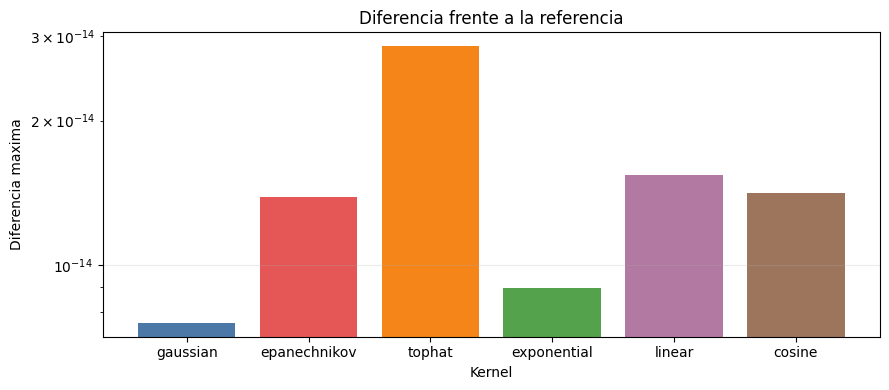

In [15]:
if validation_df is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(validation_df["kernel"], validation_df["diferencia_curva"], color=[COLOR_MAP[k] for k in validation_df["kernel"]])
    ax.set_yscale("log")
    ax.set_xlabel("Kernel")
    ax.set_ylabel("Diferencia maxima")
    ax.set_title("Diferencia frente a la referencia")
    ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


In [16]:
densities = {}
summary_rows = []

start = time.perf_counter()
for kernel in KERNELS:
    if kernel in reference_kernels:
        pdf = evaluate_kde_reference(values, x_grid, selected_bandwidth, kernel)
        metodo = "referencia"
    else:
        pdf = evaluate_kde_fast(values, x_grid, selected_bandwidth, kernel)
        metodo = "rapido"

    density, mass = normalize_conditional(pdf, x_grid)
    densities[kernel] = density
    summary_rows.append({
        "kernel": kernel,
        "metodo": metodo,
        "bandwidth": selected_bandwidth,
        "masa": mass,
        "moda_kde": mode_kde(density, x_grid),
    })
elapsed = time.perf_counter() - start

results_df = pd.DataFrame(summary_rows)
display(results_df)
print(f"Tiempo de evaluacion: {elapsed:.3f} s")


,kernel,metodo,bandwidth,masa,moda_kde
0,gaussian,rapido,265.702434,0.570649,29.706316
1,epanechnikov,rapido,265.702434,0.600720,27.153055
2,tophat,rapido,265.702434,0.584443,266.184699
3,exponential,rapido,265.702434,0.571625,5.999473
4,linear,rapido,265.702434,0.610507,5.999473
5,cosine,rapido,265.702434,0.602731,25.269382


Tiempo de evaluacion: 1.956 s


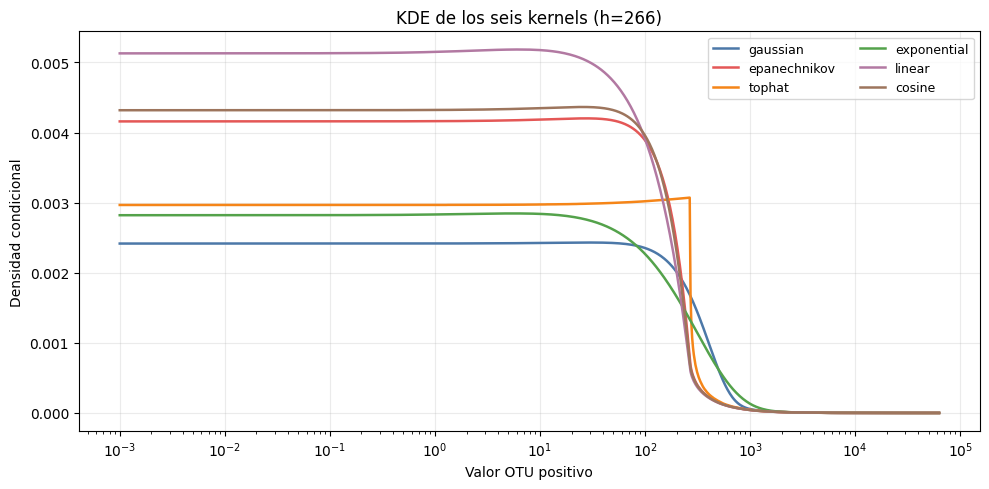

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for kernel in KERNELS:
    ax.plot(
        x_grid,
        densities[kernel],
        color=COLOR_MAP[kernel],
        linewidth=1.8,
        label=kernel,
    )

ax.set_xscale("log")
ax.set_xlabel("Valor OTU positivo")
ax.set_ylabel("Densidad condicional")
ax.set_title(f"KDE de los seis kernels (h={selected_bandwidth:.3g})")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()


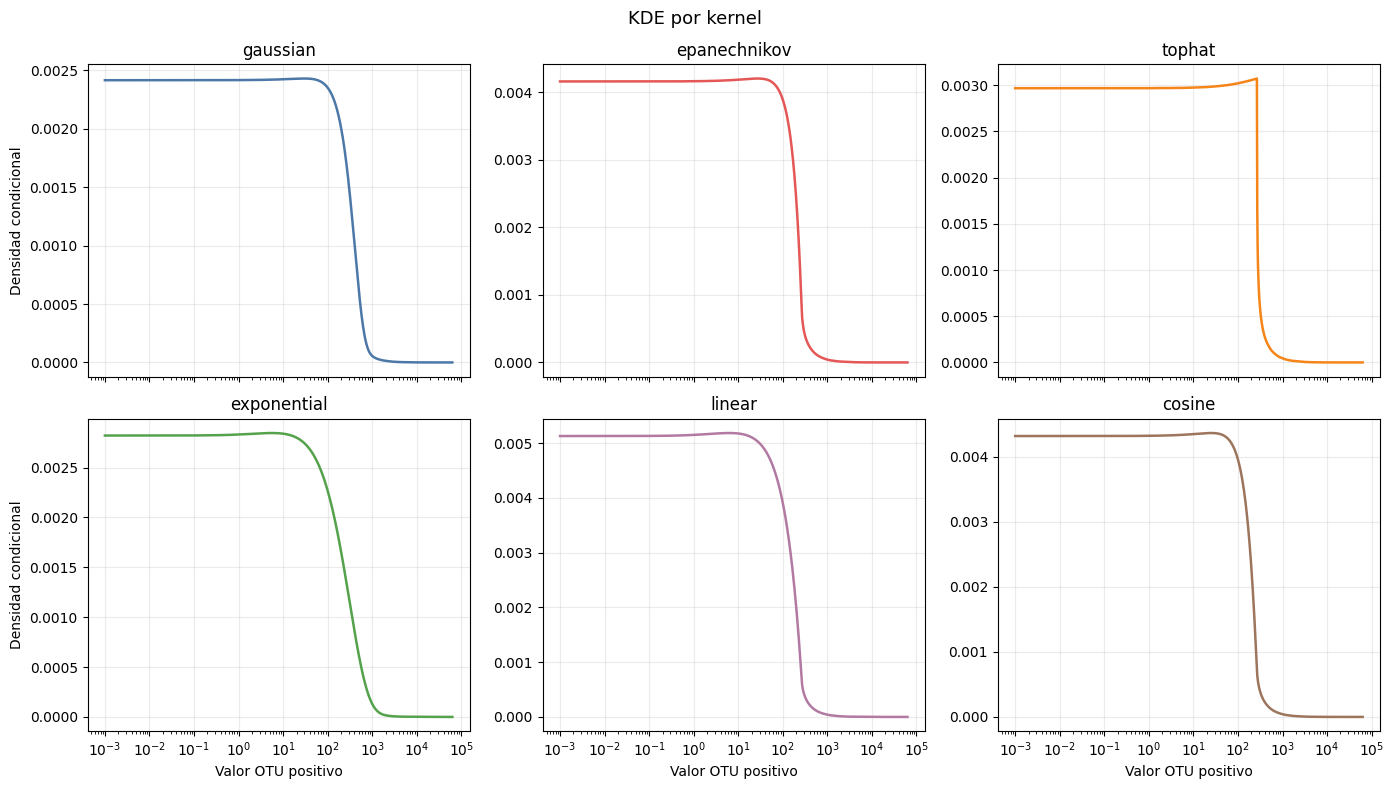

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
for ax, kernel in zip(axes.ravel(), KERNELS):
    ax.plot(x_grid, densities[kernel], color=COLOR_MAP[kernel], linewidth=1.8)
    ax.set_xscale("log")
    ax.set_title(kernel)
    ax.grid(True, alpha=0.25)

for ax in axes[-1, :]:
    ax.set_xlabel("Valor OTU positivo")
for ax in axes[:, 0]:
    ax.set_ylabel("Densidad condicional")

fig.suptitle("KDE por kernel", fontsize=13)
fig.tight_layout()
plt.show()
